<a href="https://colab.research.google.com/github/SinghAbh1shek/machine-learning/blob/main/02_Regularization_Techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Load the data
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

In [ ]:
type(housing)

sklearn.utils._bunch.Bunch

In [ ]:
housing


{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [ ]:
print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [ ]:
print(housing.feature_names)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [ ]:
print(housing.target)

[4.526 3.585 3.521 ... 0.923 0.847 0.894]


In [ ]:
print(housing.data)

[[   8.3252       41.            6.98412698 ...    2.55555556
    37.88       -122.23      ]
 [   8.3014       21.            6.23813708 ...    2.10984183
    37.86       -122.22      ]
 [   7.2574       52.            8.28813559 ...    2.80225989
    37.85       -122.24      ]
 ...
 [   1.7          17.            5.20554273 ...    2.3256351
    39.43       -121.22      ]
 [   1.8672       18.            5.32951289 ...    2.12320917
    39.43       -121.32      ]
 [   2.3886       16.            5.25471698 ...    2.61698113
    39.37       -121.24      ]]


In [ ]:
# Data Preparation

dataset = pd.DataFrame(housing.data, columns=housing.feature_names)
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
dataset.shape

(20640, 8)

In [ ]:
dataset['Price'] = housing.target
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
x = dataset.iloc[:, : -1]
y = dataset.iloc[:, -1]


In [ ]:
x

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [ ]:
y

,Price
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422
...,...
20635,0.781
20636,0.771
20637,0.923
20638,0.847


In [ ]:
# Train test split


from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=44)


In [ ]:
x_train

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
5567,2.6618,19.0,4.666667,1.142132,2047.0,3.463621,33.88,-118.28
3116,3.9261,12.0,5.657303,1.044944,1027.0,2.884831,35.63,-117.76
4750,2.5320,39.0,3.734257,1.022670,2638.0,3.322418,34.04,-118.32
13963,3.9688,15.0,16.550562,3.078652,622.0,2.329588,34.24,-116.87
2262,1.9575,24.0,4.528424,1.058140,2098.0,2.710594,36.79,-119.83
...,...,...,...,...,...,...,...,...
18528,3.2437,44.0,4.996139,1.038610,645.0,2.490347,36.96,-122.04
20355,1.9811,16.0,6.104730,1.168919,587.0,1.983108,34.19,-118.96
16955,6.0000,40.0,5.990196,1.006536,751.0,2.454248,37.53,-122.30
3491,5.1408,33.0,5.359862,0.913495,881.0,3.048443,34.27,-118.47


In [ ]:
x_test

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
20127,4.4219,34.0,5.850220,1.074890,795.0,3.502203,34.40,-118.98
18256,6.1995,36.0,6.309756,1.014634,1055.0,2.573171,37.38,-122.09
10376,10.1531,2.0,9.906329,1.130380,2985.0,3.778481,33.64,-117.62
4109,6.5533,34.0,6.431154,1.086231,1572.0,2.186370,34.14,-118.39
8169,5.0447,36.0,5.953020,1.003356,784.0,2.630872,33.81,-118.12
...,...,...,...,...,...,...,...,...
2312,3.9032,3.0,5.863330,1.192913,4432.0,2.492688,36.85,-119.74
18574,2.5599,42.0,2.826446,0.966942,2312.0,4.776860,36.91,-121.75
14552,6.4696,10.0,7.217391,0.971014,1700.0,3.519669,32.97,-117.13
1430,4.6375,28.0,6.281780,1.129237,1591.0,3.370763,38.00,-122.02


In [ ]:
y_test

,Price
20127,3.38100
18256,4.07200
10376,4.84100
4109,5.00001
8169,2.49200
...,...
2312,1.40800
18574,1.51400
14552,2.49500
1430,1.78200


In [ ]:
# Data Standardization

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


In [ ]:
x_train

array([[-6.39313890e-01, -7.70123468e-01, -3.18448077e-01, ...,
         3.12799921e-02, -8.18307745e-01,  6.42275354e-01],
       [ 2.55369484e-02, -1.32842869e+00,  9.00311043e-02, ...,
        -1.86339026e-02,  2.97361003e-05,  9.01327246e-01],
       [-7.07571138e-01,  8.25034301e-01, -7.02917949e-01, ...,
         1.91028816e-02, -7.43488318e-01,  6.22348286e-01],
       ...,
       [ 1.11612791e+00,  9.04792190e-01,  2.27296098e-01, ...,
        -5.57667090e-02,  8.88510430e-01, -1.36039504e+00],
       [ 6.64304894e-01,  3.46486970e-01, -3.26160516e-02, ...,
        -4.52430976e-03, -6.35935392e-01,  5.47621779e-01],
       [-1.22307638e+00,  1.86971194e-01, -9.59981326e-01, ...,
        -9.01614158e-02, -1.34204373e+00,  1.23510564e+00]])

In [ ]:
x_test

array([[ 2.86260705e-01,  4.26244859e-01,  1.69578464e-01, ...,
         3.46072137e-02, -5.75144608e-01,  2.93551655e-01],
       [ 1.22103793e+00,  5.85760636e-01,  3.59063490e-01, ...,
        -4.55110319e-02,  8.18367217e-01, -1.25577793e+00],
       [ 3.30009692e+00, -2.12600757e+00,  1.84207456e+00, ...,
         5.84330242e-02, -9.30536885e-01,  9.71071986e-01],
       ...,
       [ 1.36307401e+00, -1.48794446e+00,  7.33317830e-01, ...,
         3.61134621e-02, -1.24384324e+00,  1.21517858e+00],
       [ 3.99637151e-01, -5.23024719e-02,  3.47527685e-01, ...,
         2.32720415e-02,  1.10829250e+00, -1.22090556e+00],
       [-9.16129109e-01,  1.22382374e+00, -3.40511886e-01, ...,
        -3.02836919e-03, -7.62193175e-01,  6.37293587e-01]])

In [ ]:
# Model Training
# Linear Regression



from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
# Lasso Regression (L1 regularization)

from sklearn.linear_model import Lasso
model_lasso = Lasso()

In [ ]:
# Ridge Regression (L2 regularization)


from sklearn.linear_model import Ridge
model_ridge = Ridge()

In [ ]:
# Elastic Net Regression (Combination of both L1 and L2)


from sklearn.linear_model import ElasticNet
model_elastic_net = ElasticNet()

In [ ]:
model_lasso.fit(x_train, y_train)
model_ridge.fit(x_train, y_train)
model_elastic_net.fit(x_train, y_train)

ElasticNet()

In [ ]:
# Model Prediction

y_cap = model.predict(x_test)
print(y_cap)

[2.55823281 3.35684836 4.09751962 ... 2.80867915 2.38870762 1.61280809]


In [ ]:
y_cap_lasso = model_lasso.predict(x_test)
print(y_cap_lasso)

[2.0677633 2.0677633 2.0677633 ... 2.0677633 2.0677633 2.0677633]


In [ ]:
y_cap_ridge = model_ridge.predict(x_test)
print(y_cap_ridge)

[2.55805966 3.35658646 4.0975895  ... 2.80868816 2.38863631 1.61282596]


In [ ]:
y_cap_elastic_net = model_elastic_net.predict(x_test)
print(y_cap_elastic_net)

[2.12337531 2.30497493 2.70887472 ... 2.33256835 2.145401   1.88978646]


In [ ]:
print(model.coef_)
# print(len(model.coef_))

[ 0.83215514  0.11519221 -0.2633912   0.31621969 -0.00115802 -0.03990048
 -0.90741623 -0.87609073]


In [ ]:
print(model.intercept_)

2.067763302446704


In [ ]:
# Model Prediction

y_cap = model.predict(x_test)
print(y_cap)

[2.55823281 3.35684836 4.09751962 ... 2.80867915 2.38870762 1.61280809]


In [ ]:
# Model Evaluation


residual = y_test - y_cap
residual

,Price
20127,0.822767
18256,0.715152
10376,0.743480
4109,1.707415
8169,-0.172330
...,...
2312,-0.014145
18574,-0.691329
14552,-0.313679
1430,-0.606708


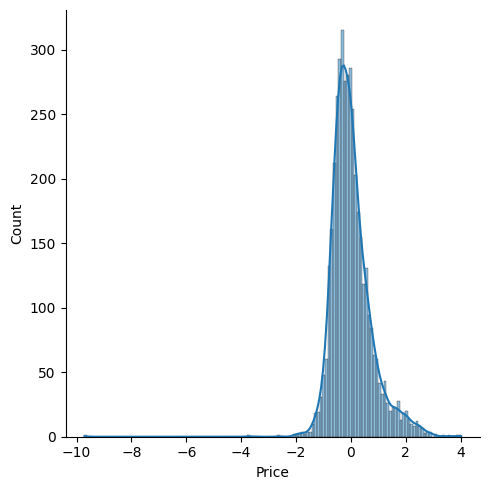

In [ ]:
#  Normaality -> Distributions plot of the above residuals == it should be normally distributed

sns.displot(residual, kde=True)

In [ ]:
# Model Evaluation


from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print(f"Mean Squere Error: {mean_squared_error(y_test, y_cap)}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_cap)}")
print(f"Mean Squere Root Error: {np.sqrt(mean_squared_error(y_test, y_cap))}")

Mean Squere Error: 0.5347838950335048
Mean Absolute Error: 0.5278504031670417
Mean Squere Root Error: 0.7312892006815804


In [ ]:
# R-squqre vs Adjusuted R-square


from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_cap)
r2

0.6084415600235555

In [ ]:
# save the model -> Pickel File

import pickle

pickle.dump(model, open('linear_reg_model.pkl', 'wb'))